# Module 1 · Can I trust this average?

**Module 1 of the spiral — the drill-down question starts here:** before we compare partner B vs A in a slice, can we even trust the *average* of a metric like EPC (revenue per click-out)? This module profiles the shape (skew, zeros, whales) on the **real NI `online_banking` click-out data** — the same grain the spine question lives on.

## Look before you leap: outliers, skew & the wall of zeros

EPC — revenue per click-out — is the number the drill-down question is built on, and the most
**dangerous to average naively**. Most click-outs earn **\$0**; a handful of conversions
(a mortgage lead!) earn hundreds. That shape — a spike at zero plus a long right tail — means
**the mean is unstable** and a single "whale" can swing your daily report.

This module: see the shape, find the outliers, and choose a summary that survives them.

In [5]:
import sys
from pathlib import Path
for _c in [Path.cwd(), *Path.cwd().parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src"))
        sys.path.insert(0, str(_c / ".claude" / "skills" / "_lib"))
        break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni      # chart style + palette
import ni_core as C        # the SAME data + primitives the /profile-data skill runs
ni.set_style()

# Click-out grain: one row per click-out, revenue = $ that click-out earned (EPC).
# This is the grain the "is partner B better than A?" question lives on.
clk = C.load_clickouts()
clicks = clk[clk["clicked"]].copy()
print(f"Loaded {len(clicks):,} click-outs | {clicks['date'].min().date()} -> {clicks['date'].max().date()}")
clicks[["date", "channel", "platform", "partner", "converted", "revenue"]].head()

Loaded 94,998 click-outs | 2026-03-01 -> 2026-05-30


,date,channel,platform,partner,converted,revenue
0,2026-03-01,Social,mobile,Summit Direct,0,0.0000
2,2026-03-01,Google,desktop,BlueRiver Checking,0,0.0000
4,2026-03-01,Organic,mobile,Summit Direct,0,0.0000
8,2026-03-01,Organic,desktop,Summit Direct,0,0.0000
9,2026-03-01,Google,mobile,NorthStar Bank,1,9.7998


## 1. The mean lies — see the shape first

Three views of the same revenue data: all visits (the zero spike), converting
visits only (the long tail), and the log-transform that tames it.

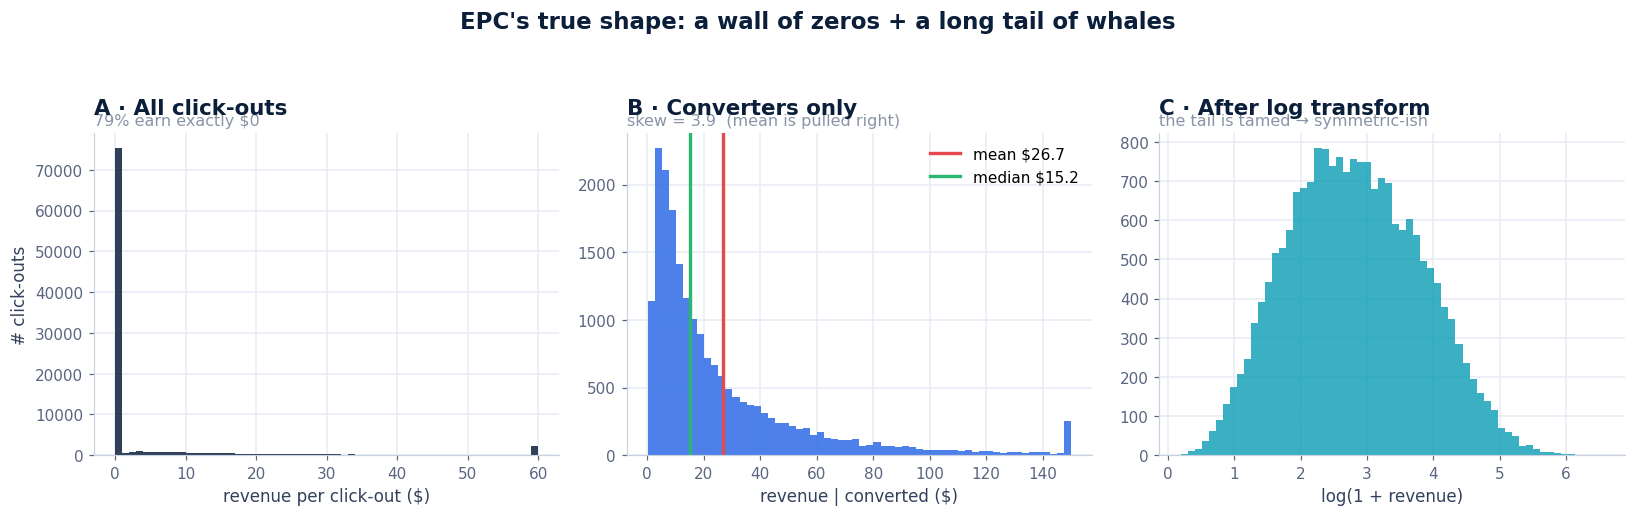

Pooled (19,809 converters): top 1% earn 8% of converter revenue.
Summit's Bing/May slice (237 click-outs, 102 visits): one visit ($514) is 17% of everything it earned.
-> Whale risk is a property of the SLICE you decide on, not of the pooled dataset.


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# A - all click-outs: the zero spike dominates
ax[0].hist(clicks["revenue"].clip(upper=60), bins=60, color=ni.NAVY, alpha=0.85)
ax[0].set_xlabel("revenue per click-out ($)"); ax[0].set_ylabel("# click-outs")
ni.titlebox(ax[0], "A · All click-outs", f"{(clicks.revenue==0).mean():.0%} earn exactly $0")

# B - converting click-outs only: heavy right tail, mean >> median
rev = clicks.loc[clicks.converted == 1, "revenue"]
ax[1].hist(rev.clip(upper=150), bins=60, color=ni.BLUE, alpha=0.85)
ax[1].axvline(rev.mean(), color=ni.RED, lw=2.2, label=f"mean ${rev.mean():.1f}")
ax[1].axvline(rev.median(), color=ni.GREEN, lw=2.2, label=f"median ${rev.median():.1f}")
ax[1].set_xlabel("revenue | converted ($)"); ax[1].legend()
ni.titlebox(ax[1], "B · Converters only", f"skew = {stats.skew(rev):.1f}  (mean is pulled right)")

# C - log1p transform: roughly symmetric, analyzable
ax[2].hist(np.log1p(rev), bins=60, color=ni.TEAL, alpha=0.85)
ax[2].set_xlabel("log(1 + revenue)")
ni.titlebox(ax[2], "C · After log transform", "the tail is tamed → symmetric-ish")

fig.suptitle("EPC's true shape: a wall of zeros + a long tail of whales",
             fontsize=15, fontweight="bold", color=ni.NAVY, y=1.06)
fig.tight_layout(); ni.savefig(fig, "m1_distributions"); plt.show()

# Pooled over ~20k converters the tail looks tame. That is the WRONG unit: decisions are
# made on SLICES. Re-ask inside the slice this workshop actually argues about.
sl = clicks[(clicks.channel=="Bing") & (clicks.month=="2026-05")
            & (clicks.partner=="Summit Direct Business")]      # the partner M0 promoted
_ced = clicks[(clicks.channel=="Bing") & (clicks.month=="2026-05")
            & (clicks.partner=="Cedar Business Bank")]
tot = sl.groupby("visit_iid")["revenue"].sum()
print(f"Pooled ({len(rev):,} converters): top 1% earn "
      f"{rev[rev>=rev.quantile(.99)].sum()/rev.sum():.0%} of converter revenue.")
print(f"Summit's Bing/May slice ({len(sl)} click-outs, {sl.visit_iid.nunique()} visits): "
      f"one visit (${tot.max():,.0f}) is {tot.max()/tot.sum():.0%} of everything it earned.")
print("-> Whale risk is a property of the SLICE you decide on, not of the pooled dataset.")

## 2. Daily EPC is mostly noise — a whale is just the clearest culprit

At ~900 click-outs/day, EPC swings violently from day to day. It is tempting to read a daily spike as
a "trend" and react — but at this resolution the number is dominated by **noise** (with the
occasional whale on top). Two things make this graph honest, and they correct a common misreading:
1. a **7-day rolling mean** shows the *real* signal hiding under the daily noise, and
2. removing each day's single biggest whale **barely calms the line** — proof the problem is
   pervasive small-n noise, not one deletable outlier.

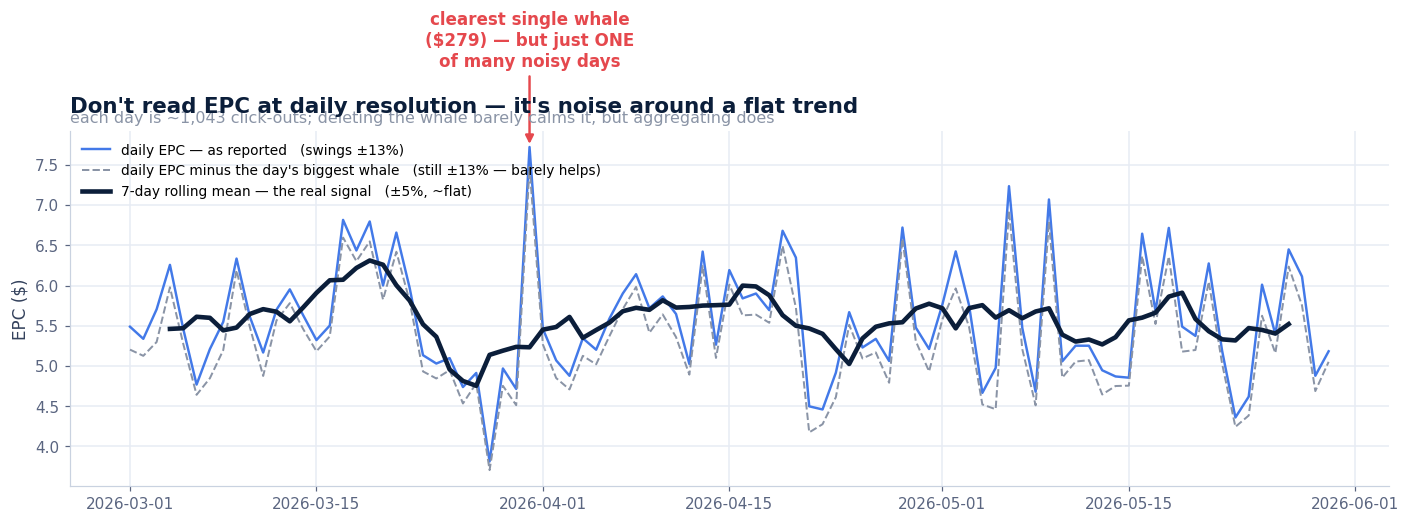

day-to-day variation (CV):  raw 13%   |   minus biggest whale 13%   |   7-day rolling 5%
Site-wide (~1,000 click-outs/day) no single whale matters — averaging protects you.

But in Summit's decision slice (102 visits):
   mean EPC        $12.60  ->  drop ONE visit  ->  $10.61   (-16%)
   GAP over Cedar  $ 5.00  ->  drop ONE visit  ->  $ 3.01   (-40%)
-> Protection scales with n. A slice thin enough to drill into is thin enough for
   one visit to move the answer -- which is exactly what happened in Module 0.


In [8]:
daily = clicks.groupby("date", observed=True).agg(
    revenue=("revenue", "sum"), clicks=("revenue", "size"), biggest=("revenue", "max")).reset_index()
daily["EPC"] = daily.revenue / daily.clicks

# (a) daily EPC with each day's single biggest conversion removed
daily["EPC_ex_whale"] = (daily.revenue - daily.biggest) / (daily.clicks - 1)
# (b) the 7-day rolling mean = the stable underlying signal (aggregation beats deletion)
daily["EPC_roll7"] = daily["EPC"].rolling(7, center=True).mean()

def cv(x):                                   # day-to-day variation = std / mean
    x = x.dropna(); return x.std() / x.mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily.date, daily.EPC, color=ni.BLUE, lw=1.6, alpha=0.9,
        label=f"daily EPC — as reported   (swings ±{cv(daily.EPC):.0%})")
ax.plot(daily.date, daily.EPC_ex_whale, color=ni.GREY, lw=1.3, ls="--",
        label=f"daily EPC minus the day's biggest whale   (still ±{cv(daily.EPC_ex_whale):.0%} — barely helps)")
ax.plot(daily.date, daily.EPC_roll7, color=ni.NAVY, lw=3,
        label=f"7-day rolling mean — the real signal   (±{cv(daily.EPC_roll7):.0%}, ~flat)")
spike = daily.loc[daily.EPC.idxmax()]
ax.annotate(f"clearest single whale\n(${spike.biggest:,.0f}) — but just ONE\nof many noisy days",
            xy=(spike.date, spike.EPC), xytext=(spike.date, spike.EPC * 1.13),
            ha="center", color=ni.RED, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=ni.RED, lw=1.6))
ax.set_ylabel("EPC ($)"); ax.legend(loc="upper left", fontsize=9)
ni.titlebox(ax, "Don't read EPC at daily resolution — it's noise around a flat trend",
            f"each day is ~{int(daily.clicks.mean()):,} click-outs; deleting the whale barely calms it, but aggregating does")
fig.tight_layout(); ni.savefig(fig, "m1_whale_timeseries"); plt.show()

print(f"day-to-day variation (CV):  raw {cv(daily.EPC):.0%}   |   minus biggest whale "
      f"{cv(daily.EPC_ex_whale):.0%}   |   7-day rolling {cv(daily.EPC_roll7):.0%}")
print("Site-wide (~1,000 click-outs/day) no single whale matters — averaging protects you.")
print()

# The same question at the grain decisions are actually made on:
sl_g = sl.groupby("visit_iid")["revenue"].sum()
top  = sl_g.idxmax()
mean_all  = sl.revenue.mean()
mean_less = sl[sl.visit_iid != top].revenue.mean()
gap_all, gap_less = mean_all - _ced.revenue.mean(), mean_less - _ced.revenue.mean()
print(f"But in Summit's decision slice ({sl.visit_iid.nunique()} visits):")
print(f"   mean EPC        ${mean_all:5.2f}  ->  drop ONE visit  ->  ${mean_less:5.2f}   ({(mean_less-mean_all)/mean_all:+.0%})")
print(f"   GAP over Cedar  ${gap_all:5.2f}  ->  drop ONE visit  ->  ${gap_less:5.2f}   ({(gap_less-gap_all)/gap_all:+.0%})")
print("-> Protection scales with n. A slice thin enough to drill into is thin enough for")
print("   one visit to move the answer -- which is exactly what happened in Module 0.")

> **So which spikes do we ignore? All of them.** The marked day is just the one where a *single*
> conversion is the obvious culprit — but the de-whaled line proves the rest of the line is *equally*
> erratic for diffuse reasons (small n + multiple whales + day-of-week mix). This is Module 1's wide
> daily sampling distribution in time-series form. The rule isn't "ignore that one peak" — it's
> **never act on a single day's EPV; read the 7-day trend, or test the difference properly.**

## 3. Finding outliers: visual + rule-based

Boxplots on a **log scale** reveal the whales by partner; the IQR and z-score
rules flag them numerically. (Note: with skewed data the IQR rule is more
trustworthy than the z-score, which is itself distorted by the outliers.)

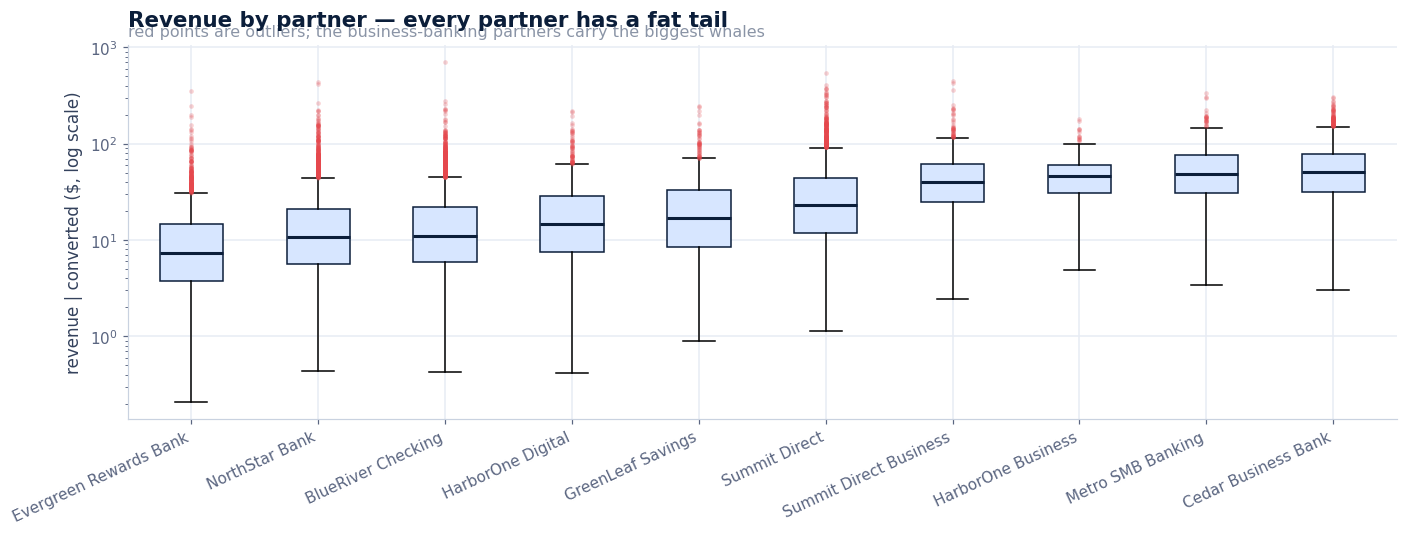

Converting click-outs flagged as high outliers:  IQR rule = 1,469   |   z>3 rule = 401
→ The IQR rule catches the heavy tail; the z-score under-flags because the whales inflate the SD.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
conv = clicks[clicks.converted == 1]
order = conv.groupby("partner")["revenue"].median().sort_values().index.tolist()
data = [conv.loc[conv.partner == p, "revenue"].values for p in order]
bp = ax.boxplot(data, vert=True, patch_artist=True, tick_labels=order, showfliers=True,
                flierprops=dict(marker="o", markersize=3, alpha=0.25, markerfacecolor=ni.RED, markeredgecolor="none"))
for patch in bp["boxes"]:
    patch.set(facecolor=ni.LIGHT, edgecolor=ni.NAVY)
for med in bp["medians"]:
    med.set(color=ni.NAVY, linewidth=2)
ax.set_yscale("log"); ax.set_ylabel("revenue | converted ($, log scale)")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ni.titlebox(ax, "Revenue by partner — every partner has a fat tail",
            "red points are outliers; the business-banking partners carry the biggest whales")
fig.tight_layout(); ni.savefig(fig, "m1_outliers_box"); plt.show()

# Rule-based counts
def outlier_counts(x):
    q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
    iqr_out = (x > q3 + 1.5*iqr).sum()
    z = (x - x.mean())/x.std(); z_out = (np.abs(z) > 3).sum()
    return iqr_out, z_out
io, zo = outlier_counts(rev.values)
print(f"Converting click-outs flagged as high outliers:  IQR rule = {io:,}   |   z>3 rule = {zo:,}")
print("→ The IQR rule catches the heavy tail; the z-score under-flags because the whales inflate the SD.")

## 4. Does the choice of summary change the decision?

Mean vs median vs 5%-trimmed mean by **platform**. Watch what happens: the **median is \$0**
for both — most click-outs earn nothing, so the median throws away the whole signal here.
The **mean** is inflated by whales, but the **5%-trimmed mean** is the robust summary that
stays stable *and* still preserves the desktop-vs-mobile gap we care about.

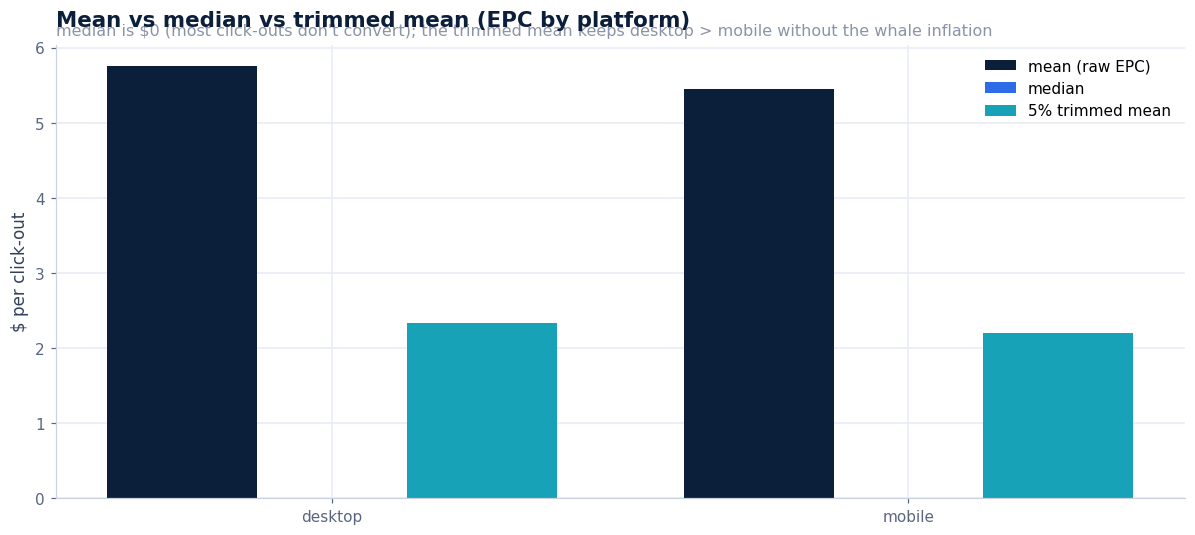

,mean (raw EPC),median,5% trimmed mean
platform,,,
desktop,5.75,0.0,2.34
mobile,5.45,0.0,2.21


In [5]:
def trimmed_mean(x, p=0.05): return stats.trim_mean(x, p)
g = clicks.groupby("platform", observed=True)["revenue"]
summ = pd.DataFrame({
    "mean (raw EPC)": g.mean(),
    "median": g.median(),
    "5% trimmed mean": g.apply(lambda s: trimmed_mean(s.values)),
}).reindex(["desktop", "mobile"])

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summ)); w = 0.26
for i, col in enumerate(summ.columns):
    ax.bar(x + (i-1)*w, summ[col], w, label=col, color=[ni.NAVY, ni.BLUE, ni.TEAL][i])
ax.set_xticks(x); ax.set_xticklabels(summ.index); ax.set_ylabel("$ per click-out")
ax.legend()
ni.titlebox(ax, "Mean vs median vs trimmed mean (EPC by platform)",
            "median is $0 (most click-outs don't convert); the trimmed mean keeps desktop > mobile without the whale inflation")
fig.tight_layout(); ni.savefig(fig, "m1_robust_summaries"); plt.show()
display(summ.round(2))

### ✅ Takeaway

> **Always plot the distribution before you quote an average.**
> For EPC at NI: report the **mean** (it's what the business banks) **but** sanity-check the
> shape first. On this zero-inflated data the **median is $0 and useless** — reach instead for the
> **trimmed mean** or a **bootstrap**, flag outliers with the **IQR rule** (not the z-score), and
> consider a **log transform** for any test. A spike in mean EPC is a *whale question* before it's
> a *trend question*.

**Next:** now that we respect EPC's shape, *how much independent data* is really behind that
average when click-outs share visits? → **Module 2.**

**→ The skill that automates this:** `/profile-data`. Next: **Module 2 — how much data is really here?** (i.i.d. / effective-n).